In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import load_model

In [24]:
df = pd.read_csv("../dataset/clean_dataset_sample.csv")

X = df.drop("Label", axis=1)

y = df["Label"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
autoencoder = load_model("../models/lstm_autoencoder.keras")

print("LSTM Autoencoder Loaded Successfully!")

LSTM Autoencoder Loaded Successfully!


In [27]:
X_train_normal = X_train[y_train == 0]

In [28]:
X_train_lstm = np.expand_dims(
    X_train_normal.values,
    axis=1
)

X_test_lstm = np.expand_dims(
    X_test.values,
    axis=1
)

print(X_train_lstm.shape)
print(X_test_lstm.shape)

(177482, 1, 80)
(60000, 1, 80)


In [29]:
train_pred = autoencoder.predict(X_train_lstm)

train_loss = np.mean(
    np.square(train_pred - X_train_lstm),
    axis=(1,2)
)

print(train_loss[:10])

5547/5547 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
[0.00024108 0.00020911 0.00020024 0.00884409 0.00012244 0.00993671
 0.00011204 0.00176503 0.00012806 0.00017053]


In [30]:
threshold = np.percentile(train_loss, 99)

print("New Threshold:", threshold)



New Threshold: 0.05326621322328276


In [31]:
test_pred = autoencoder.predict(X_test_lstm)

test_loss = np.mean(
    np.square(test_pred - X_test_lstm),
    axis=(1,2)
)

print(test_loss[:10])

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
[0.00072042 0.00014701 0.00047486 0.00018196 0.00145173 0.00021105
 0.00054927 0.00223079 0.00048655 0.00761042]


In [32]:
pred = (test_loss > threshold).astype(int)

print(classification_report(y_test, pred))

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision :", precision_score(y_test, pred))
print("Recall :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      0.99      0.90     44370
           1       0.93      0.43      0.58     15630

    accuracy                           0.84     60000
   macro avg       0.88      0.71      0.74     60000
weighted avg       0.86      0.84      0.82     60000

Accuracy : 0.8422166666666666
Precision : 0.930918752622011
Recall : 0.42591170825335894
F1 Score : 0.5844343970852903


In [33]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      0.99      0.90     44370
           1       0.93      0.43      0.58     15630

    accuracy                           0.84     60000
   macro avg       0.88      0.71      0.74     60000
weighted avg       0.86      0.84      0.82     60000



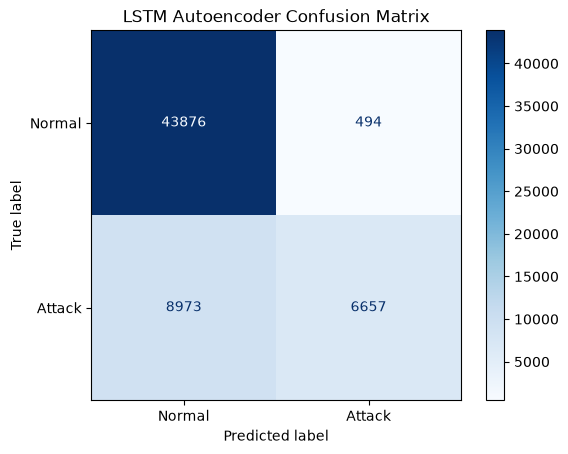

In [34]:
cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal","Attack"]
)

disp.plot(cmap="Blues")

plt.title("LSTM Autoencoder Confusion Matrix")

plt.show()

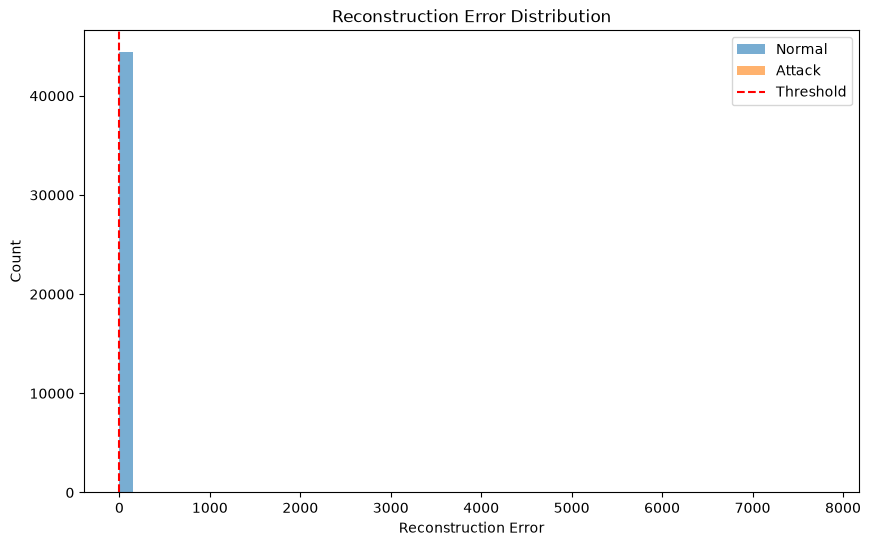

In [35]:
plt.figure(figsize=(10,6))

plt.hist(
    test_loss[y_test==0],
    bins=50,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    test_loss[y_test==1],
    bins=50,
    alpha=0.6,
    label="Attack"
)

plt.axvline(
    threshold,
    color="red",
    linestyle="--",
    label="Threshold"
)

plt.legend()

plt.title("Reconstruction Error Distribution")

plt.xlabel("Reconstruction Error")

plt.ylabel("Count")

plt.show()

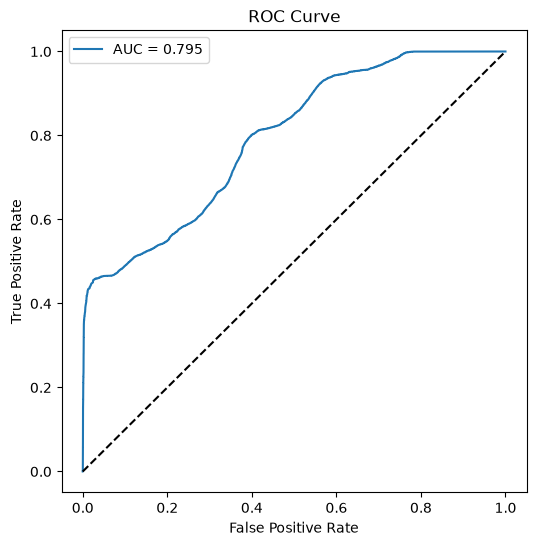

In [36]:
fpr, tpr, _ = roc_curve(y_test, test_loss)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [40]:
plt.savefig(
    "../results/lstm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

In [42]:
import os
import pandas as pd

os.makedirs("../results", exist_ok=True)

results = pd.DataFrame({
    "Actual": y_test,
    "Prediction": pred,
    "Reconstruction_Error": test_loss
})

results.to_csv(
    "../results/lstm_predictions.csv",
    index=False
)

print("Evaluation Results Saved Successfully!")

Evaluation Results Saved Successfully!
